*Proyecto Final - Probabilidad y Estadística para la Gestión de Datos.*

*Tecnicatura en Ciencia de Datos e IA*

*Prof.: Gonzalo Ducca*

*Alumno: Nahuelanca Maximiliano*


---

# **Introducción**

Este proyecto tiene como objetivo integrar los contenidos de la materia
mediante el análisis de un conjunto de datos económicos simulados.
Se trabajará con las librerías pandas, matplotlib y scikit-learn.

---
# **1. Importación de librerías**






In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Librerias importadas")

Librerias importadas




---


# **2. Carga del conjunto de datos**

Este conjunto de datos vincula los hábitos de estilo de vida del estudiantes con el rendimiento académico.




In [3]:
df = pd.read_csv('./habitos_estudiantes.csv')

print("Dataset cargado. Primeras 5 filas: \n")

df.head()

Dataset cargado. Primeras 5 filas: 



,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4




---


# **3. Estadísticos descriptivos**

Inicialmente mostramos un resumen estadistico del dataset

In [ ]:
print("Resumen estadístico:\n")

print(df.describe())

Resumen estadístico:

             age  study_hours_per_day  social_media_hours  netflix_hours  \
count  1000.0000           1000.00000         1000.000000    1000.000000   
mean     20.4980              3.55010            2.505500       1.819700   
std       2.3081              1.46889            1.172422       1.075118   
min      17.0000              0.00000            0.000000       0.000000   
25%      18.7500              2.60000            1.700000       1.000000   
50%      20.0000              3.50000            2.500000       1.800000   
75%      23.0000              4.50000            3.300000       2.525000   
max      24.0000              8.30000            7.200000       5.400000   

       attendance_percentage  sleep_hours  exercise_frequency  \
count            1000.000000  1000.000000         1000.000000   
mean               84.131700     6.470100            3.042000   
std                 9.399246     1.226377            2.025423   
min                56.000000     

Verificamos el **tipo de dato** que contiene cada coluimna

In [ ]:
df.dtypes

,0
student_id,object
age,int64
gender,object
study_hours_per_day,float64
social_media_hours,float64
netflix_hours,float64
part_time_job,object
attendance_percentage,float64
sleep_hours,float64
diet_quality,object


**Corroboramos puntualmente algunas variables de interes**

*MEDIA, PROMEDIO*

In [ ]:
media_horas_estudio = df['study_hours_per_day'].mean() #horas_de_estudio_por_día
media_edad = df['age'].mean() #edad
media_horas_rrss = df['social_media_hours'].mean() #horas_de_redes_sociales
media_horas_sueño = df['sleep_hours'].mean() #horas_de_sueno

print(f"Media de horas de estudio por dia: {media_horas_estudio:.2f} hs\n")
print(f"Media de edad: {media_edad:.2f}\n")
print(f"Media de horas de uso de redes sociales por dia: {media_horas_rrss:.2f} hs\n")
print(f"Media de horas de sueño: {media_horas_sueño:.2f} hs")


Media de horas de estudio por dia: 3.55 hs

Media de edad: 20.50

Media de horas de uso de redes sociales por dia: 2.51 hs

Media de horas de sueño: 6.47 hs


*DESVIO ESTANDAR*

In [ ]:
std_horas_estudio = df['study_hours_per_day'].std() #horas_de_estudio_por_día
std_edad = df['age'].std() #edad
std_horas_rrss = df['social_media_hours'].std() #horas_de_redes_sociales
std_horas_sueño = df['sleep_hours'].std() #horas_de_sueno

print(f"Desvio estandar de horas de estudio por dia: {std_horas_estudio:.2f}\n")
print(f"Desvio estandar de la edad: {std_edad:.2f}\n")
print(f"Desvio estandar de horas de uso de redes sociales por dia: {std_horas_rrss:.2f}\n")
print(f"Desvio estandar de horas de sueño: {std_horas_sueño:.2f}")

Desvio estandar de horas de estudio por dia: 1.47

Desvio estandar de la edad: 2.31

Desvio estandar de horas de uso de redes sociales por dia: 1.17

Desvio estandar de horas de sueño: 1.23




---


# **4. Visualizaciones**




Distribucion de edad de los estudiantes

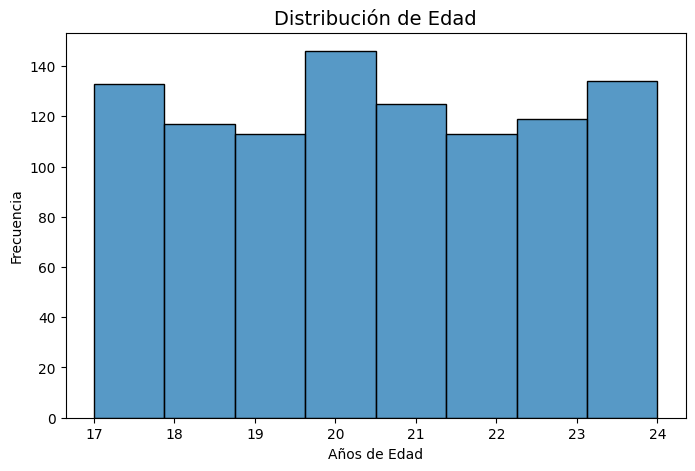

,count
age,
17,133
18,117
19,113
20,146
21,125
22,113
23,119
24,134


In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=8, edgecolor='black')
plt.title('Distribución de Edad', fontsize=14)
plt.xlabel('Años de Edad')
plt.ylabel('Frecuencia')
plt.show()

# Frecuencias de edad
df['age'].value_counts().sort_index()

Porcentaje de estudiantes que trabajan a tiempo parcial o no trabajan

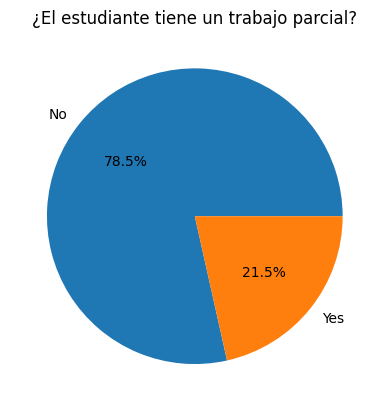



Cantidad de estudiantes que tienen trabajo parcial: 215.0
Cantidad de estudiantes que no tienen trabajo parcial: 785.0


In [ ]:
var = df['part_time_job'].value_counts()
plt.pie(x=var, labels=var.index, autopct='%1.1f%%') # var.index usa las etiquetas reales ('No', 'Yes')
plt.title('¿El estudiante tiene un trabajo parcial?')
plt.show()

procentaje_no = 1000*0.785
procentaje_si = 1000*0.215

print("\n")
print(f"Cantidad de estudiantes que tienen trabajo parcial: {procentaje_si}")
print(f"Cantidad de estudiantes que no tienen trabajo parcial: {procentaje_no}")

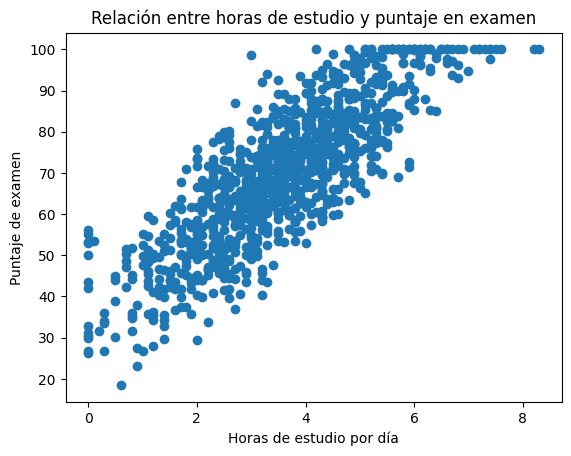



En el gráfico de dispersión se observa claramente que a medida que aumentan las horas de estudio por día, también aumenta el puntaje del examen.
Vemos estudiantes que con las mismas horas de estudio obtienen notas muy diferentes (por ejemplo, algunos con 4 horas sacan 50 y otros 90)


In [ ]:
plt.figure()
plt.scatter(df['study_hours_per_day'], df['exam_score'])
plt.title('Relación entre horas de estudio y puntaje en examen')
plt.xlabel('Horas de estudio por día')
plt.ylabel('Puntaje de examen')
plt.show()

print("\n")
print("En el gráfico de dispersión se observa claramente que a medida que aumentan las horas de estudio por día, también aumenta el puntaje del examen.")
print("Vemos estudiantes que con las mismas horas de estudio obtienen notas muy diferentes (por ejemplo, algunos con 4 horas sacan 50 y otros 90)")

Relacion entre puntaje en examen y horas en las redes sociales

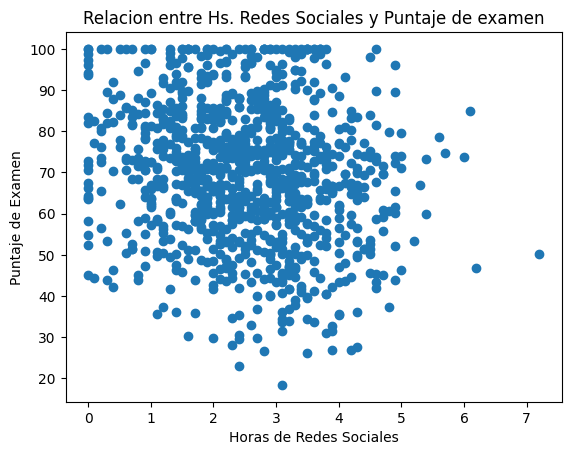



Por lo general, cuando disminuyen las horas de redes sociales, el puntaje del examen tiende a aumentar un poco.
La relación es débil y no se puede afirmar que las redes sociales expliquen de forma importante el puntaje del examen
Hay estudiantes que usan muchas redes sociales (4-5 horas) y aun así logran notas decentes, y otros que usan pocas y tienen notas bajas. 
Esto sugiere que las redes sociales son un factor secundario, no determinante.


In [ ]:
plt.figure()
plt.scatter(df['social_media_hours'], df['exam_score'])
plt.title('Relacion entre Hs. Redes Sociales y Puntaje de examen')
plt.xlabel('Horas de Redes Sociales')
plt.ylabel('Puntaje de Examen')
plt.show()

print("\n")
print("Por lo general, cuando disminuyen las horas de redes sociales, el puntaje del examen tiende a aumentar un poco.\nLa relación es débil y no se puede afirmar que las redes sociales expliquen de forma importante el puntaje del examen")
print("Hay estudiantes que usan muchas redes sociales (4-5 horas) y aun así logran notas decentes, y otros que usan pocas y tienen notas bajas. \nEsto sugiere que las redes sociales son un factor secundario, no determinante.")

Relacion entre puntaje de examen y porcentaje de asistencia a clase

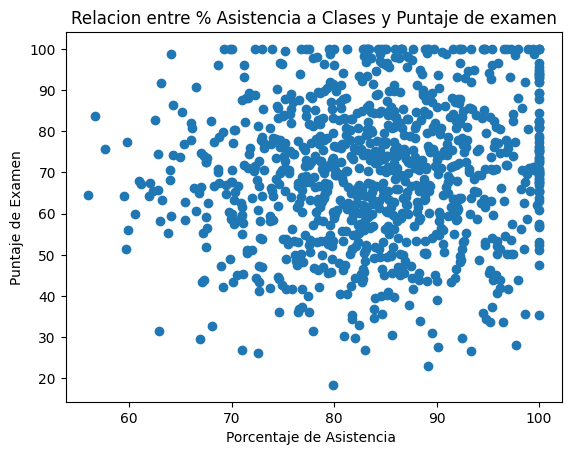



En promedio, a mayor asistencia el puntaje tiende a subir un poco, pero la relación es baja, por ello no tiene poder explicativo
La variabilidad es tan alta que la asistencia por sí sola no garantiza una buena nota


In [ ]:
plt.figure()
plt.scatter(df['attendance_percentage'], df['exam_score'])
plt.title('Relacion entre % Asistencia a Clases y Puntaje de examen')
plt.xlabel('Porcentaje de Asistencia ')
plt.ylabel('Puntaje de Examen')
plt.show()

print("\n")
print("En promedio, a mayor asistencia el puntaje tiende a subir un poco, pero la relación es baja, por ello no tiene poder explicativo")
print("La variabilidad es tan alta que la asistencia por sí sola no garantiza una buena nota")

Box-Plot

Distribución de Notas: ¿El trabajo afecta el rendimiento?

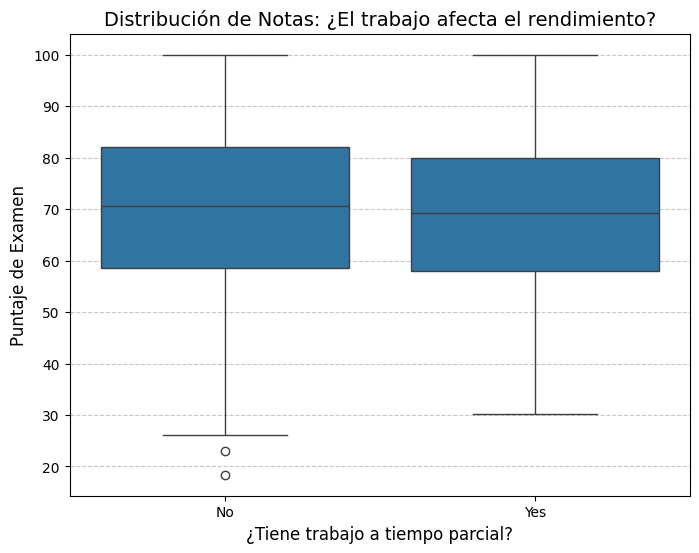




1. Medianas:
Las líneas centrales de ambos grupos están casi a la misma altura (alrededor de 70 puntos).
Conclusión: En promedio, el rendimiento académico es prácticamente idéntico.
Tener un trabajo a tiempo parcial no parece desplazar el centro de las calificaciones hacia abajo de manera significativa.

2. Dispersión:
La altura de las cajas es muy similar en ambos casos.
Conclusión: La variabilidad en las notas es igual en ambos grupos. No es que los que trabajan sean 'más inestables' en sus notas

3. Valores Atípicos:
Curiosamente, los Outliers (las notas excepcionalmente bajas, por debajo de 30) aparecen en el grupo 'No' (los que no trabajan).
Conclusión: Los estudiantes con peor rendimiento en este dataset resultaron ser aquellos que no tienen trabajo.
Esto podría indicar que el tiempo libre extra no necesariamente se usa para estudiar, o que hay otros factores (motivación, problemas personales) afectando a esos casos extremos.


Descripcion general de puntaje examen:
         e

In [16]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='part_time_job',
            y='exam_score',
            data=df,
            )
plt.title('Distribución de Notas: ¿El trabajo afecta el rendimiento?', fontsize=14)
plt.xlabel('¿Tiene trabajo a tiempo parcial?', fontsize=12)
plt.ylabel('Puntaje de Examen', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\n")

print(f"""
1. Medianas:
Las líneas centrales de ambos grupos están casi a la misma altura (alrededor de 70 puntos).
Conclusión: En promedio, el rendimiento académico es prácticamente idéntico.
Tener un trabajo a tiempo parcial no parece desplazar el centro de las calificaciones hacia abajo de manera significativa.

2. Dispersión:
La altura de las cajas es muy similar en ambos casos.
Conclusión: La variabilidad en las notas es igual en ambos grupos. No es que los que trabajan sean 'más inestables' en sus notas

3. Valores Atípicos:
Curiosamente, los Outliers (las notas excepcionalmente bajas, por debajo de 30) aparecen en el grupo 'No' (los que no trabajan).
Conclusión: Los estudiantes con peor rendimiento en este dataset resultaron ser aquellos que no tienen trabajo.
Esto podría indicar que el tiempo libre extra no necesariamente se usa para estudiar, o que hay otros factores (motivación, problemas personales) afectando a esos casos extremos.

""")

general = df[['exam_score']].describe()
siTrabaja = df[df['part_time_job'] == 'Yes']['exam_score'].describe()
NoTrabaja = df[df['part_time_job'] == 'No']['exam_score'].describe()

print(f"Descripcion general de puntaje examen:\n", general)
print("\n")
print(f"Descripcion general de puntaje examen SI trabaja:\n",siTrabaja)
print("\n")
print(f"Descripcion general de puntaje examen NO trabaja:\n",NoTrabaja)




---


# **5. Correlación**


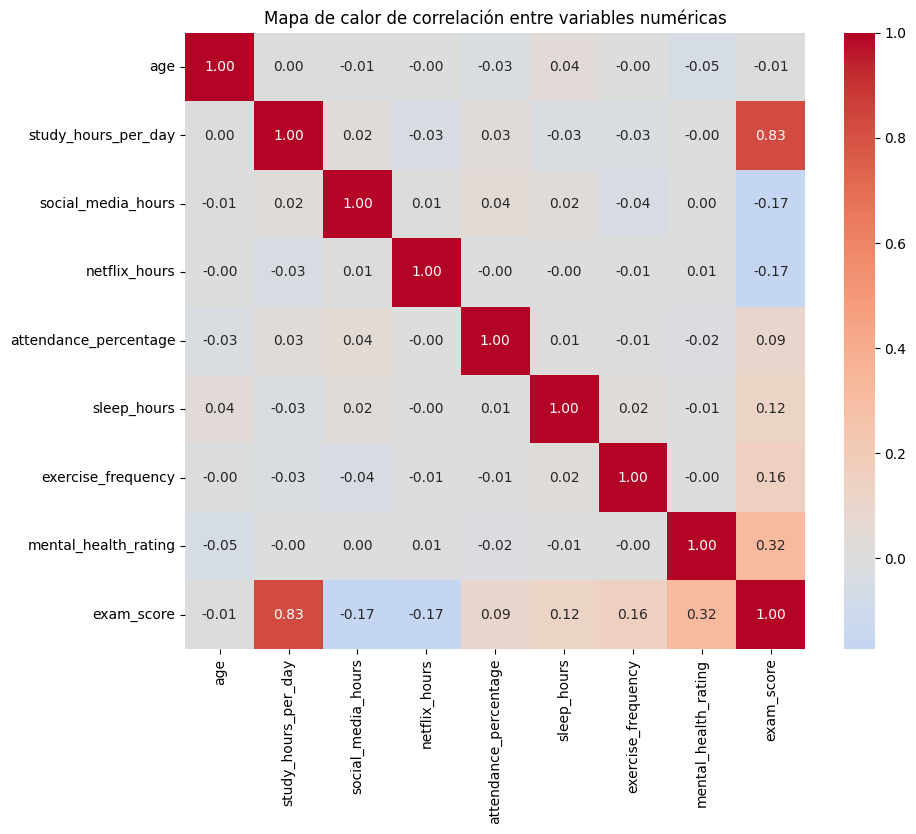




1 indica una correlación muy alta y positiva: cuando una variable sube, la otra también sube siempre en la misma proporción.

0 indicaría que no hay relación lineal entre las variables.

–0.17 indica una relación débil y negativa: cuando una variable sube, la otra tiende a bajar, pero de forma muy leve.

Los valores intermedios representan grados de relación más fuertes o más débiles.



In [ ]:
# Seleccionamos solo columnas numéricas
numericas = df.select_dtypes(include=['int64', 'float64'])
corr = numericas.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Mapa de calor de correlación entre variables numéricas')
plt.show()

print("\n")
print("""
1 indica una correlación muy alta y positiva: cuando una variable sube, la otra también sube siempre en la misma proporción.

0 indicaría que no hay relación lineal entre las variables.

–0.17 indica una relación débil y negativa: cuando una variable sube, la otra tiende a bajar, pero de forma muy leve.

Los valores intermedios representan grados de relación más fuertes o más débiles.
""")



---


# **6. Regresión lineal simple**

Utilizamos una regresión lineal para estudiar como las 'horas de estudio por día' influyen en el 'puntaje del examen'
El modelo responde a: ¿Cuantos puntos en el examen sacará un estudiante según las horas que estudia por día?
Modelo: Puntaje de examen = Intercepto + Pendiente × Horas de estudio por día

Modelo: Puntaje de examen = 35.91 + 9.49 * Horas de estudio por día




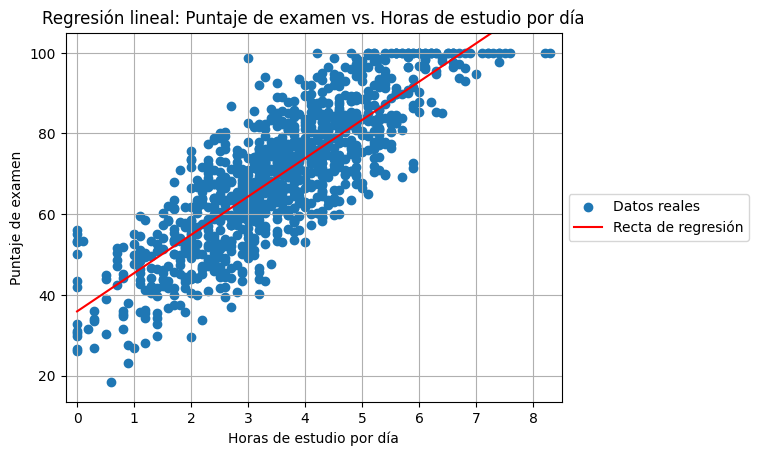

In [ ]:
# Predice exam_score (y) a partir de study_hours_per_day (x)
print("Utilizamos una regresión lineal para estudiar como las 'horas de estudio por día' influyen en el 'puntaje del examen'")
print("El modelo responde a: ¿Cuantos puntos en el examen sacará un estudiante según las horas que estudia por día?")

X = df[['study_hours_per_day']]
y = df['exam_score']

modelo = LinearRegression()
modelo.fit(X, y)

print("Modelo: Puntaje de examen = Intercepto + Pendiente × Horas de estudio por día")
print(f"\nModelo: Puntaje de examen = {modelo.intercept_:.2f} + {modelo.coef_[0]:.2f} * Horas de estudio por día")
print("\n")


plt.figure()
plt.scatter(X, y, label='Datos reales')

# Linea de regresión
X_line = np.linspace(X.min().iloc[0], X.max().iloc[0], 100)
plt.plot(X_line, modelo.intercept_ + modelo.coef_[0] * X_line, 'r', label='Recta de regresión')

plt.title('Regresión lineal: Puntaje de examen vs. Horas de estudio por día')
plt.xlabel('Horas de estudio por día')
plt.ylabel('Puntaje de examen')
plt.xlim(X.min().iloc[0] - 0.2, X.max().iloc[0] + 0.2)
plt.ylim(y.min() - 5, y.max() + 5)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()
plt.show()



---


# **7. Evaluación del modelo**

In [ ]:
y_pred = modelo.predict(X)
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print(f"""
Estas métricas se usan para evaluar qué tan buenas son las predicciones del modelo:
MAE (Mean Absolute Error): Es el error promedio absoluto entre lo que el modelo predijo y la realidad. Cuanto menor sea el MAE, mejor.
                          En promedio, el modelo se equivoca por 7.7 puntos en el examen.
    MAE: {mae:.2f}

MSE (Mean Squared Error): Toma los errores, los eleva al cuadrado y calcula el promedio. Cuanto menor sea el MSE, mejor.
                          Un MSE de 90 es normal si los puntajes de examen van de 0 a 100.
    MSE: {mse:.2f}

RMSE (Root Mean Squared Error): Es la raíz cuadrada del MSE. Cuanto menor sea el RMSE, mejor.
                                El modelo se equivoca típicamente unos 9.5 puntos.
    RMSE: {rmse:.2f}

R²: Es el coeficiente de determinación. Cuanto mayor sea el R², mejor.
    Mide qué porcentaje de la variación del puntaje de examen es explicado por las horas de estudio.
    El 68.1% del puntaje del examen se explica por cuántas horas estudia la persona.
    El otro 31.9% se debe a otras cosas: sueño, estrés, capacidad, distracciones, azar, etc.
    R²: {r2:.3f}

En resumen, el modelo presenta un MAE de 7.71 y un RMSE de 9.53, lo que significa que el modelo se equivoca en promedio entre 7 y 10 puntos.
El valor R² = 0.681 indica que el 68.1% de la variación del puntaje de examen puede explicarse únicamente por las horas de estudio,
lo cual refleja una relación fuerte para ser un modelo con una sola variable independiente.
""")


Estas métricas se usan para evaluar qué tan buenas son las predicciones del modelo:
MAE (Mean Absolute Error): Es el error promedio absoluto entre lo que el modelo predijo y la realidad. Cuanto menor sea el MAE, mejor.
                          En promedio, el modelo se equivoca por 7.7 puntos en el examen.
    MAE: 7.71

MSE (Mean Squared Error): Toma los errores, los eleva al cuadrado y calcula el promedio. Cuanto menor sea el MSE, mejor.
                          Un MSE de 90 es normal si los puntajes de examen van de 0 a 100.
    MSE: 90.81

RMSE (Root Mean Squared Error): Es la raíz cuadrada del MSE. Cuanto menor sea el RMSE, mejor.
                                El modelo se equivoca típicamente unos 9.5 puntos.
    RMSE: 9.53

R²: Es el coeficiente de determinación. Cuanto mayor sea el R², mejor.
    Mide qué porcentaje de la variación del puntaje de examen es explicado por las horas de estudio.
    El 68.1% del puntaje del examen se explica por cuántas horas estudia la person



---


# **8. Reflexión y conclusiones**

A través del análisis de este conjunto de datos de estudiantes, hemos podido cuantificar cómo los hábitos diarios impactan en el rendimiento académico.

* ***Horas de Estudio***: Presenta una correlación fuerte y positiva. Es, sin duda, el predictor más fiable del éxito en este grupo.


* ***Asistencia***: El análisis exploratorio mostró que otro factores como la asistencia y las horas de sueño juegan roles secundarios como potenciadores del rendimiento.


* ***Redes Sociales***: Se observó una correlación débil y negativa. Si bien no es una causa directa de fracaso, el uso excesivo tiende a restar puntos levemente.


* ***El Trabajo***: Uno de los hallazgos más interesantes surgió al analizar la variable categórica `part_time_job`. Contrario a la creencia inicial, trabajar no disminuye el promedio de notas. De hecho, los casos de rendimiento extremadamente bajo (outliers) se vieron en los estudiantes que no cuentan con un trabajo parcial.

* Finalmente, podemos decir que aunque la correlación es clara, no logramos asegurar que estudiar mas horas sea la **`única`** causa para aumentar el puntaje en los examenes. Existen **variables no medidas** que son responsables del 32% que nuestro modelo no pudo explicar.
